In [1]:
import numpy as np
import matplotlib.pyplot as plt
from xtcav2.DarkBackgroundReference import DarkBackgroundReference

In [2]:
dark_ref1 = DarkBackgroundReference(
	experiment='cxil1037623', 
	run_number='75',
	#max_shots=500
)

dark background reference
	 Experiment: cxil1037623
	 Run: 75
	 Valid shots to process: 401
99.8 % done, 400 / 401
Maximum number of images processed


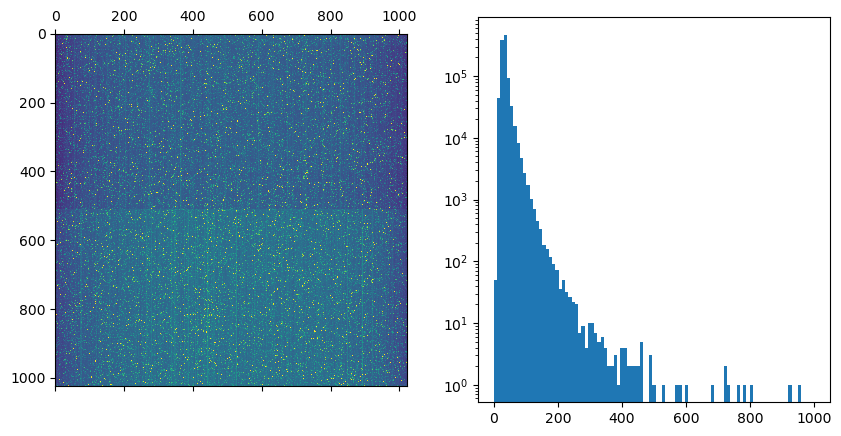

In [3]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.matshow(dark_ref1.image,vmin=0,vmax=1e2)
ax2.hist(dark_ref1.image.ravel(), bins=np.linspace(0,1000,100))
ax2.semilogy()
plt.show()

## Get dark reference images for all epochs

In [4]:
# Setup containers

# Epoch dark runs
epochal_dark_indices = {
    'B' : 75,
    'C' : 75,
    'D' : 116,
    'E' : 152,
    'F' : 182,
    'G' : 215,
    'H' : 215,
    'I' : 267,
    'J' : 293,
}

# main dictionary
epoch_dict = {}
for k,v in epochal_dark_indices.items():
    epoch_dict[k] = {
        'ind' : v,
        'done' : False,
        'darkref': -1
    }

# shapes
N = len(epoch_dict)
s = dark_ref1.image.shape
N_unique = 0

# containers
_inds_ar = np.zeros(N,dtype=int)
_darkrefs_ar = np.empty((N,s[0],s[1]))

In [5]:
# Get dark reference images

# loop
N_unique = 0
for loop_index,(k,v) in enumerate(epoch_dict.items()):
    ind = v['ind']
    # are there other indices of this value?
    for key in epoch_dict.keys():
        if key != k:
            val = epoch_dict[key]['ind']
            if val == ind:
                # if indices match, has this ref already been found?
                if epoch_dict[key]['done'] == True:
                    # update dark ref
                    epoch_dict[k]['darkref'] = epoch_dict[key]['darkref']
                    epoch_dict[k]['done'] = True
                    break
    # is this ref done?
    if not epoch_dict[k]['done']:
        # if not, populate the ref
        run_number_string = str(ind)
        darkref = DarkBackgroundReference(
        	experiment='cxil1037623', 
        	run_number=run_number_string,
        	max_shots=1000
        ).image
        epoch_dict[k]['darkref'] = darkref
        epoch_dict[k]['done'] = True
        _inds_ar[loop_index] = ind
        _darkrefs_ar[loop_index] = darkref
        N_unique += 1
        
print()
print(f"Done. Found {N_unique} unique dark reference images")
#print(epoch_dict)

dark background reference
	 Experiment: cxil1037623
	 Run: 75
	 Valid shots to process: 1000
100.0 % done, 1000 / 1000
Maximum number of images processed
dark background reference
	 Experiment: cxil1037623
	 Run: 116
	 Valid shots to process: 1000
100.0 % done, 1000 / 1000
Maximum number of images processed
dark background reference
	 Experiment: cxil1037623
	 Run: 152
	 Valid shots to process: 1000
100.0 % done, 1000 / 1000
Maximum number of images processed
dark background reference
	 Experiment: cxil1037623
	 Run: 182
	 Valid shots to process: 1000
100.0 % done, 1000 / 1000
Maximum number of images processed
dark background reference
	 Experiment: cxil1037623
	 Run: 215
	 Valid shots to process: 1000
100.0 % done, 1000 / 1000
Maximum number of images processed
dark background reference
	 Experiment: cxil1037623
	 Run: 267
	 Valid shots to process: 1000
100.0 % done, 1000 / 1000
Maximum number of images processed
dark background reference
	 Experiment: cxil1037623
	 Run: 293
	 Valid 

## Analysis of dark ref images

How different or similar are they?  The aim is to understand how much the dark background varied during the experiment to understand
1. how essential it is to use new references for each epoch,
2. how likely it is the the dark ref varied during an epoch, and
3. begin to quantify expected noise levels in our data.

In [6]:
# Repackage dark ref array for analysis

mask = _inds_ar != 0
inds_ar = _inds_ar[mask]
darkrefs_ar = _darkrefs_ar[mask]

Showing dark ref from run 75


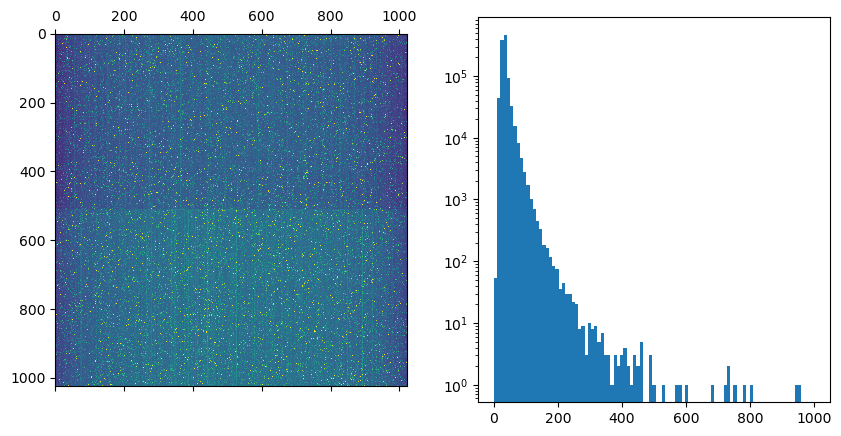

Showing dark ref from run 116


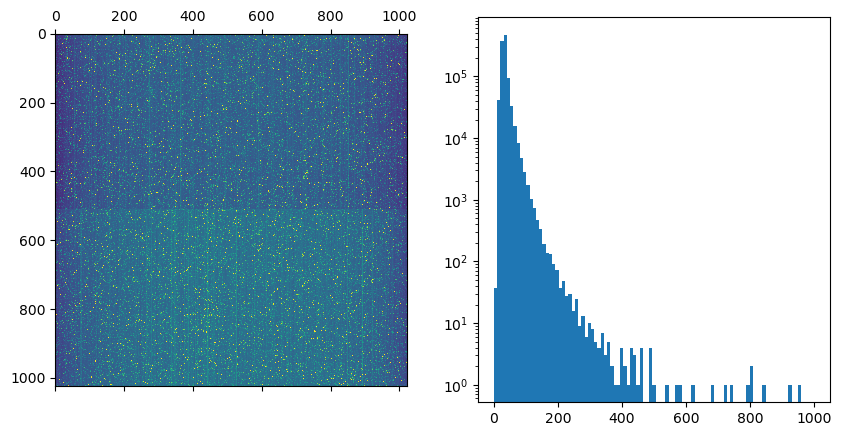

Showing dark ref from run 152


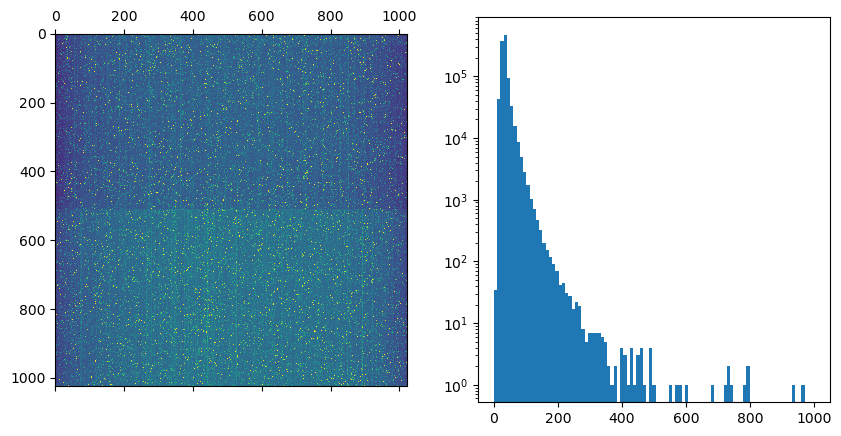

Showing dark ref from run 182


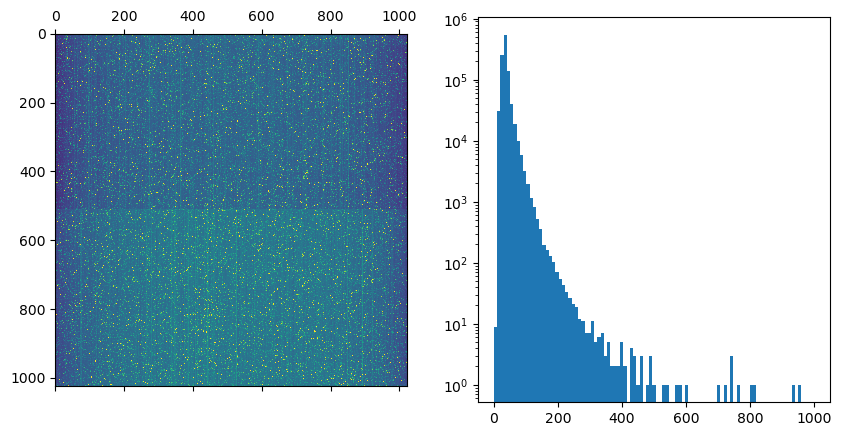

Showing dark ref from run 215


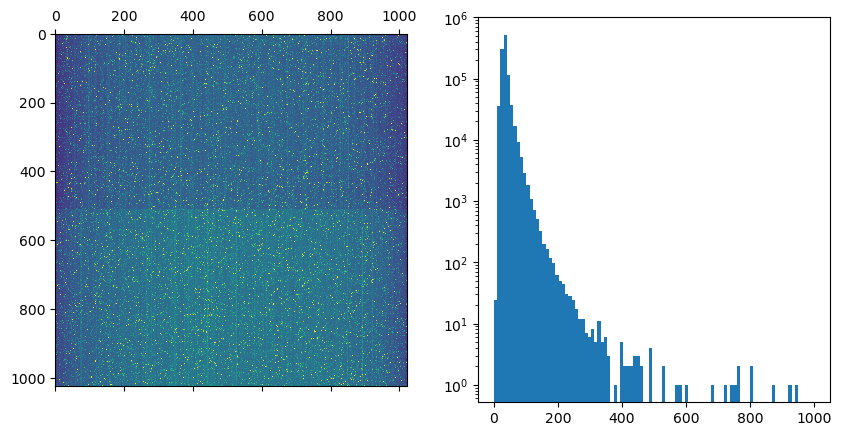

Showing dark ref from run 267


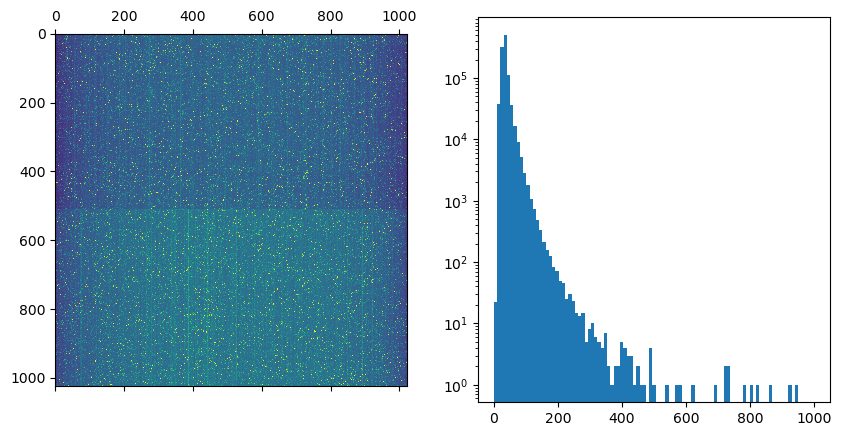

Showing dark ref from run 293


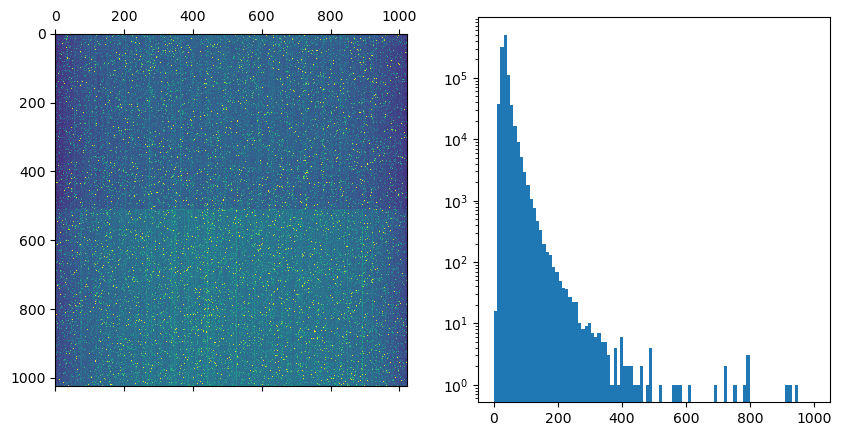

In [7]:
# Show images

for ind,im in zip(inds_ar,darkrefs_ar):
    print(f"Showing dark ref from run {ind}")
    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
    ax1.matshow(im,vmin=0,vmax=1e2)
    ax2.hist(im.ravel(), bins=np.linspace(0,1000,100))
    ax2.semilogy()
    plt.show()

The L2 norm of the difference of runs 75 and 116 is 560060.1909999999


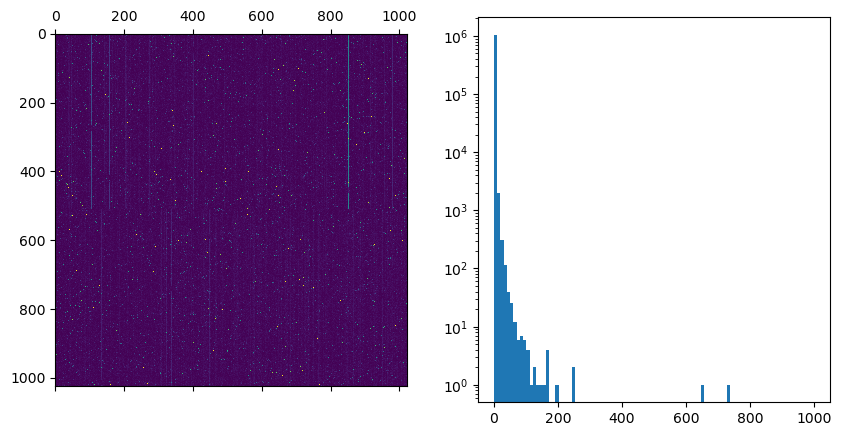

In [8]:
# Show difference

i,j = 0,1

im1 = darkrefs_ar[i]
im2 = darkrefs_ar[j]

diff_im = np.sqrt(np.square(im1-im2))
diff = np.sum(diff_im)

print(f"The L2 norm of the difference of runs {inds_ar[i]} and {inds_ar[j]} is {diff}")

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.matshow(diff_im,vmin=0,vmax=2e1)
ax2.hist(diff_im.ravel(), bins=np.linspace(0,1000,100))
ax2.semilogy()
plt.show()

The L2 norm of the difference of runs 75 and 152 is 557633.759


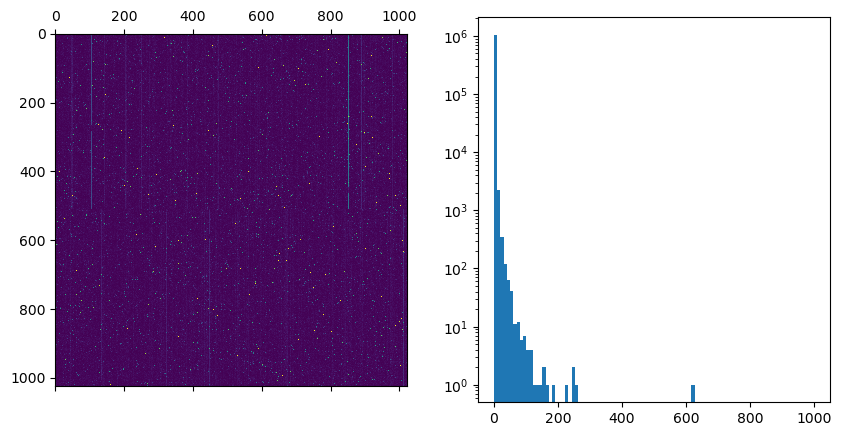

In [9]:
# Show difference

i,j = 0,2

im1 = darkrefs_ar[i]
im2 = darkrefs_ar[j]

diff_im = np.sqrt(np.square(im1-im2))
diff = np.sum(diff_im)

print(f"The L2 norm of the difference of runs {inds_ar[i]} and {inds_ar[j]} is {diff}")

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.matshow(diff_im,vmin=0,vmax=2e1)
ax2.hist(diff_im.ravel(), bins=np.linspace(0,1000,100))
ax2.semilogy()
plt.show()

The L2 norm of the difference of runs 116 and 152 is 506821.90800000017


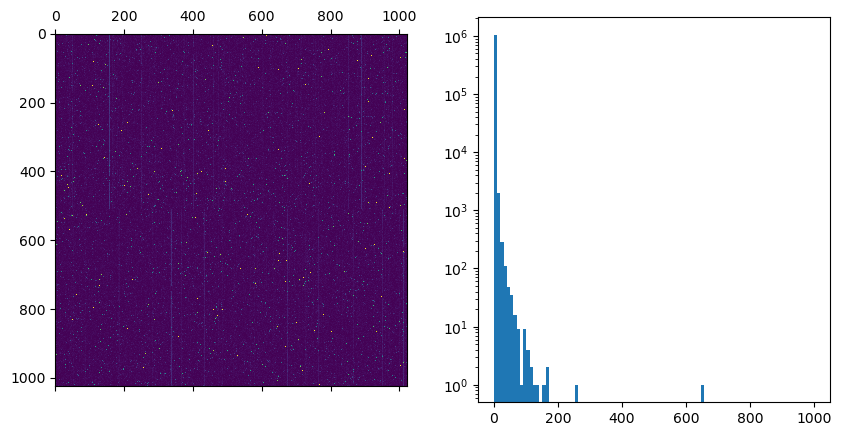

In [10]:
# Show difference

i,j = 1,2

im1 = darkrefs_ar[i]
im2 = darkrefs_ar[j]

diff_im = np.sqrt(np.square(im1-im2))
diff = np.sum(diff_im)

print(f"The L2 norm of the difference of runs {inds_ar[i]} and {inds_ar[j]} is {diff}")

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.matshow(diff_im,vmin=0,vmax=2e1)
ax2.hist(diff_im.ravel(), bins=np.linspace(0,1000,100))
ax2.semilogy()
plt.show()

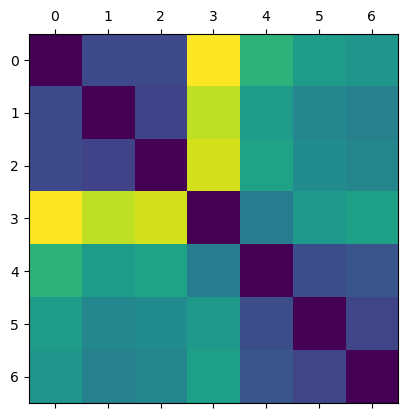

In [18]:
# Array of diffs

diffs_ar = np.zeros((N_unique,N_unique))
for i in range(N_unique):
    for j in range(i+1,N_unique):
        diffs_ar[i,j] = np.sum(np.sqrt(np.square(darkrefs_ar[i]-darkrefs_ar[j])))
for i in range(N_unique):
    for j in range(i):
        diffs_ar[i,j] = diffs_ar[j,i]

fig,ax = plt.subplots()
ax.matshow(diffs_ar)
plt.show()

vmin=506821.90800000017, vmax=2534810.4900000007


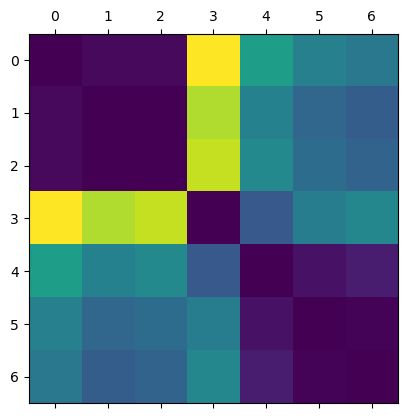

In [12]:
vmin = 1e10
for i in range(N_unique):
    for j in range(i):
        if diffs_ar[i,j] < vmin:
            vmin = diffs_ar[i,j]
vmax = np.max(diffs_ar)

print(f"vmin={vmin}, vmax={vmax}")

fig,ax = plt.subplots()
ax.matshow(diffs_ar,vmin=vmin,vmax=vmax)
plt.show()

The L2 norm of the difference of runs 75 and 182 is 2534810.4900000007


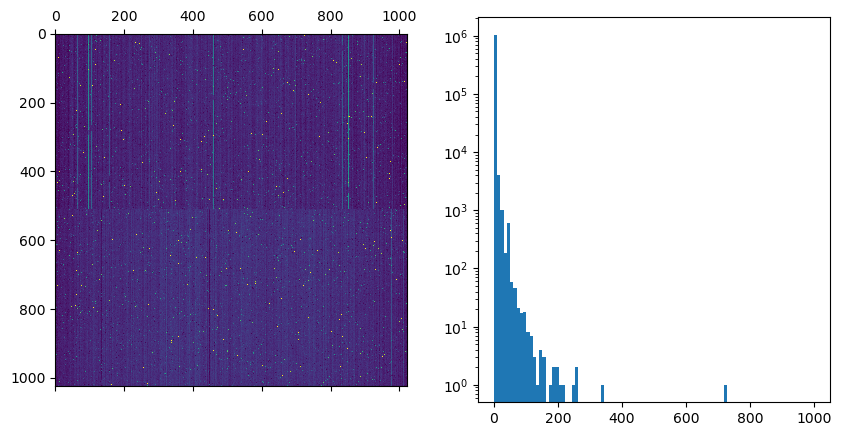

In [13]:
# Show difference

i,j = 0,3

im1 = darkrefs_ar[i]
im2 = darkrefs_ar[j]

diff_im = np.sqrt(np.square(im1-im2))
diff = np.sum(diff_im)

print(f"The L2 norm of the difference of runs {inds_ar[i]} and {inds_ar[j]} is {diff}")

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.matshow(diff_im,vmin=0,vmax=2e1)
ax2.hist(diff_im.ravel(), bins=np.linspace(0,1000,100))
ax2.semilogy()
plt.show()

The L2 norm of the difference of runs 293 and 182 is 1441961.5219999994


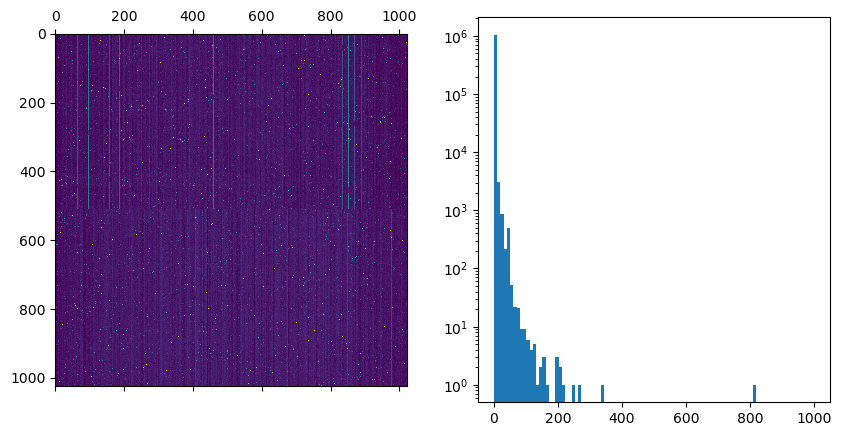

In [14]:
# Show difference

i,j = 6,3

im1 = darkrefs_ar[i]
im2 = darkrefs_ar[j]

diff_im = np.sqrt(np.square(im1-im2))
diff = np.sum(diff_im)

print(f"The L2 norm of the difference of runs {inds_ar[i]} and {inds_ar[j]} is {diff}")

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.matshow(diff_im,vmin=0,vmax=2e1)
ax2.hist(diff_im.ravel(), bins=np.linspace(0,1000,100))
ax2.semilogy()
plt.show()

The L2 norm of the difference of runs 293 and 267 is 528787.3390000003


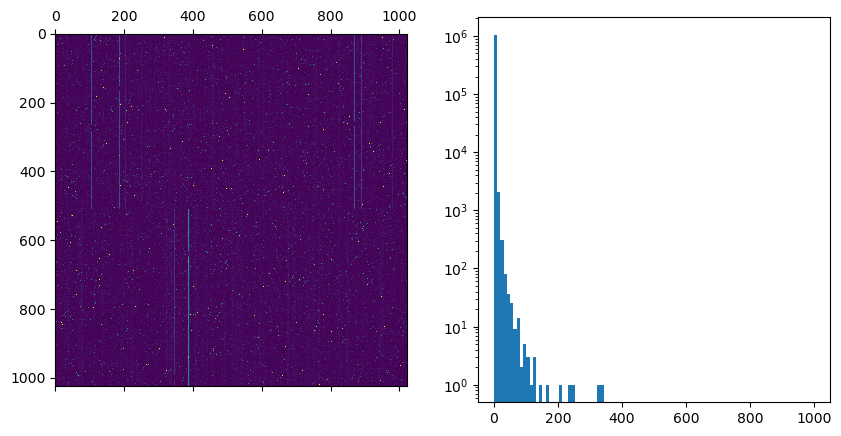

In [15]:
# Show difference

i,j = 6,5

im1 = darkrefs_ar[i]
im2 = darkrefs_ar[j]

diff_im = np.sqrt(np.square(im1-im2))
diff = np.sum(diff_im)

print(f"The L2 norm of the difference of runs {inds_ar[i]} and {inds_ar[j]} is {diff}")

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.matshow(diff_im,vmin=0,vmax=2e1)
ax2.hist(diff_im.ravel(), bins=np.linspace(0,1000,100))
ax2.semilogy()
plt.show()

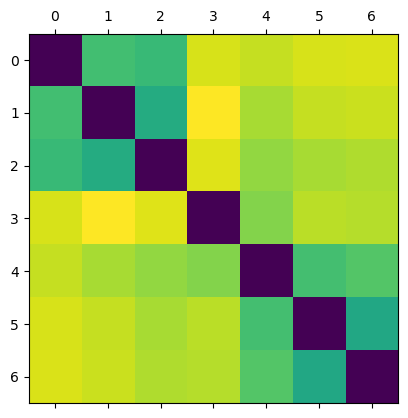

In [19]:
# Array of diffs standard deviations

diffs_stds_ar = np.zeros((N_unique,N_unique))
for i in range(N_unique):
    for j in range(i+1,N_unique):
        diffs_stds_ar[i,j] = np.sum(np.std(darkrefs_ar[i]-darkrefs_ar[j]))
for i in range(N_unique):
    for j in range(i):
        diffs_stds_ar[i,j] = diffs_stds_ar[j,i]

fig,ax = plt.subplots()
ax.matshow(diffs_stds_ar)
plt.show()

vmin=1.7428020465689427, vmax=2.4951324892743356


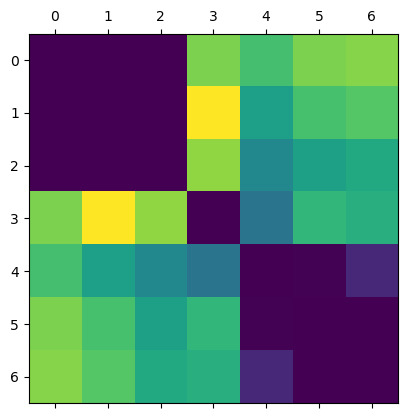

In [20]:
vmin = 1e10
for i in range(N_unique):
    for j in range(i):
        if diffs_ar[i,j] < vmin:
            vmin = diffs_stds_ar[i,j]
vmax = np.max(diffs_stds_ar)

print(f"vmin={vmin}, vmax={vmax}")

fig,ax = plt.subplots()
ax.matshow(diffs_stds_ar,vmin=vmin,vmax=vmax)
plt.show()

## Save

Save as numpy .npz file for now; change to .h5 after env is setup with `emdfile`

In [23]:
dpath = "/sdf/home/b/bsavitzk/data_tmp/"
path = dpath + "dark_references_L10376.npz"

In [24]:
np.savez(path, darkrefs_ar=darkrefs_ar, inds_ar=inds_ar)

### Load

In [25]:
data = np.load(path)

In [27]:
_darkrefs = data['darkrefs_ar']
_inds = data['inds_ar']

The L2 norm of the difference of runs 75 and 116 is 560060.1909999999


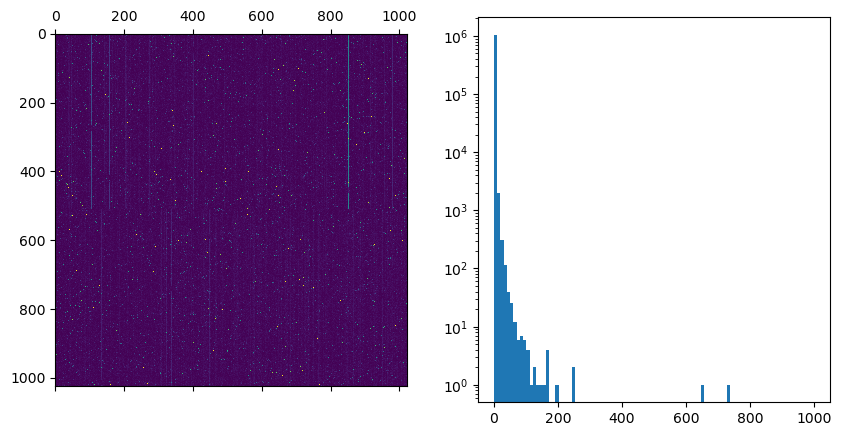

In [28]:
# Show difference

i,j = 0,1

im1 = _darkrefs[i]
im2 = _darkrefs[j]

diff_im = np.sqrt(np.square(im1-im2))
diff = np.sum(diff_im)

print(f"The L2 norm of the difference of runs {_inds[i]} and {_inds[j]} is {diff}")

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.matshow(diff_im,vmin=0,vmax=2e1)
ax2.hist(diff_im.ravel(), bins=np.linspace(0,1000,100))
ax2.semilogy()
plt.show()

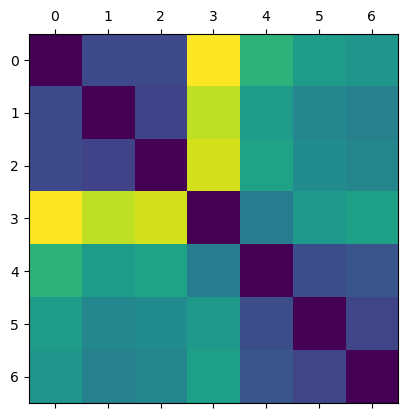

In [29]:
# Array of diffs

_diffs_ar = np.zeros((N_unique,N_unique))
for i in range(N_unique):
    for j in range(i+1,N_unique):
        _diffs_ar[i,j] = np.sum(np.sqrt(np.square(_darkrefs[i]-_darkrefs[j])))
for i in range(N_unique):
    for j in range(i):
        _diffs_ar[i,j] = _diffs_ar[j,i]

fig,ax = plt.subplots()
ax.matshow(_diffs_ar)
plt.show()